# Atividade 1 - Aprendizado Supervisionado

Luís Antônio Almeida Lima Vieira
RA: 221045

# Parte 1: Projeto Prático - Detecção de Fraude


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import precision_recall_curve, f1_score, auc, confusion_matrix, precision_score, recall_score, average_precision_score
from numpy.linalg import inv

In [2]:
database = pd.read_csv('/content/drive/MyDrive/Aprendizado_Supervisionado/creditcard.csv')
database.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## 1. Análise Exploratória e Pré-Processamento (Simplificados)

### Database information

In [ ]:
database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
database.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Balanceamento das classes

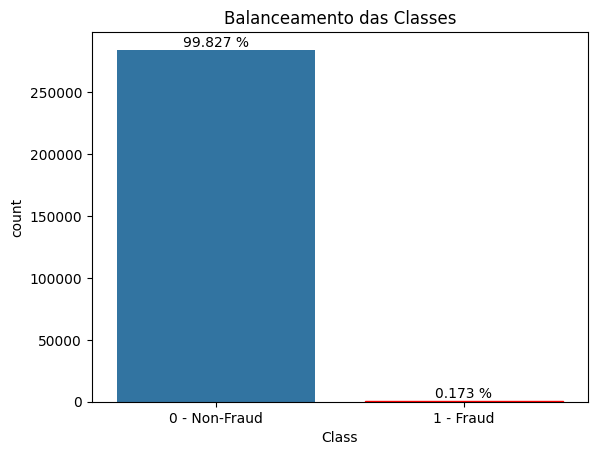

In [ ]:
ax = sns.countplot(x='Class', data=database)
plt.title('Balanceamento das Classes')

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f'{(p.get_height()/len(database))*100:.3f} %',
        ha='center',
        va='bottom'
    )
ax.set_xticks(range(len(ax.patches)))
ax.set_xticklabels(['0 - Non-Fraud', '1 - Fraud'])
ax.patches[1].set_color('red')

### Distribuições

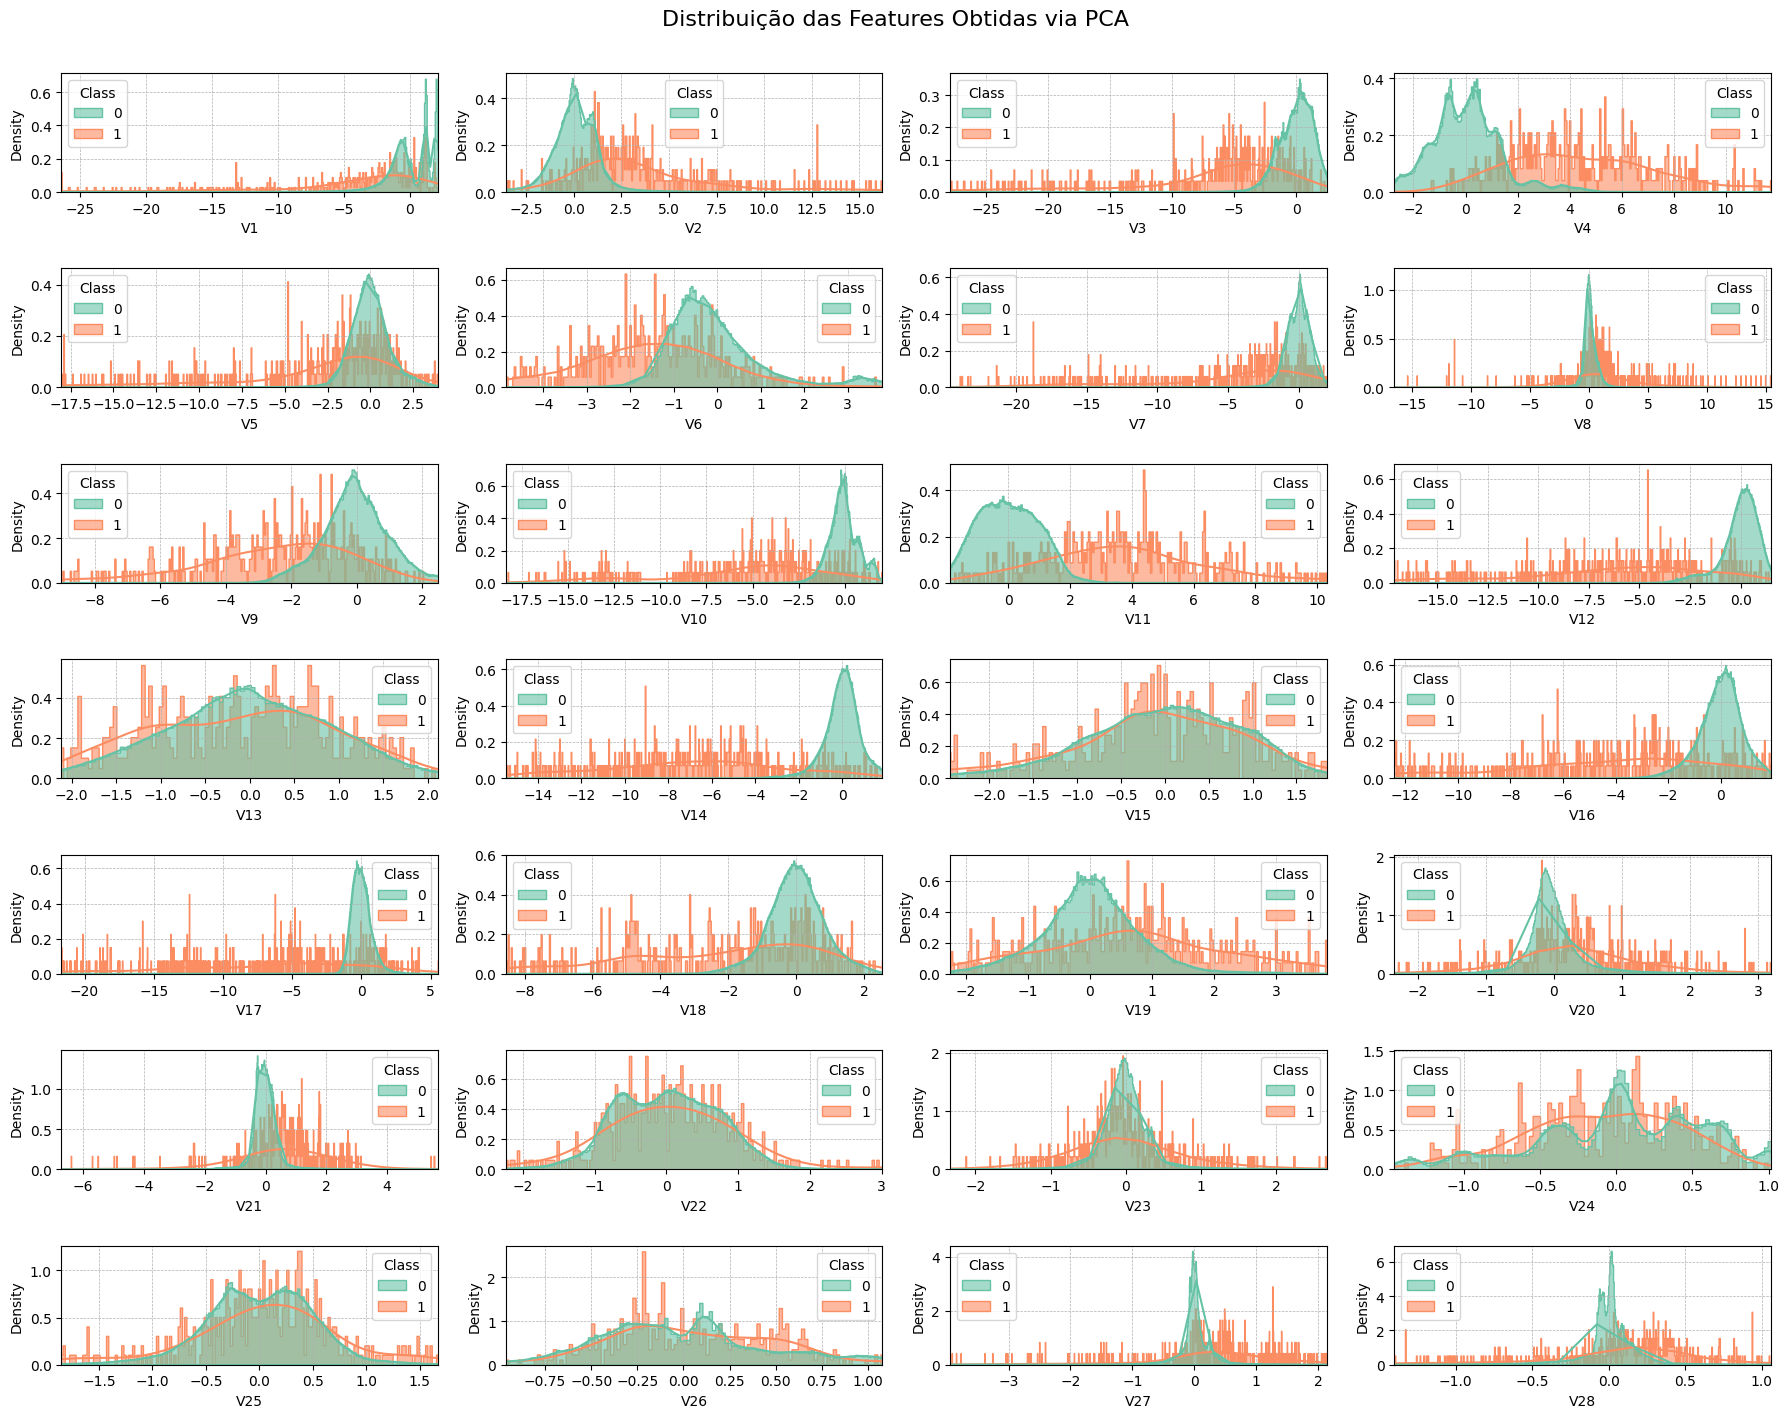

In [ ]:
fig, ax = plt.subplots(7,4, figsize=(18, 14))

plt.suptitle('Distribuição das Features Obtidas via PCA', fontsize=16,  y=1.01)
for i, col in enumerate(database.drop(columns=['Time', 'Amount', 'Class']).columns):
  min_limit = min(database[database['Class'] == 0][col].quantile(0.02), database[database['Class'] == 1][col].quantile(0.02))
  max_limit = max(database[database['Class'] == 0][col].quantile(0.98), database[database['Class'] == 1][col].quantile(0.98))
  sns.histplot(
      data=database,
      x=col,
      hue='Class',
      element='step',
      stat='density',
      common_norm=False,
      kde=True,
      ax=ax.flatten()[i],
      palette='Set2',
      alpha=0.6,
  )
  ax.flatten()[i].grid(True, linestyle='--', linewidth=0.5)
  ax.flatten()[i].set_xlim(min_limit, max_limit)


plt.tight_layout(h_pad=2.0)
plt.show()

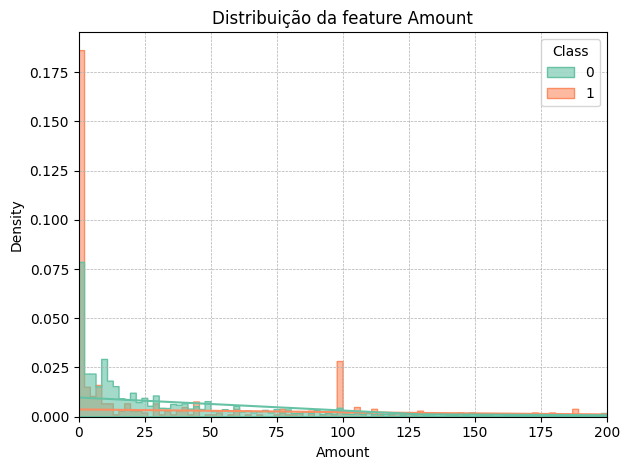

In [ ]:
plt.title('Distribuição da feature Amount')

ax = sns.histplot(
      data=database,
      x='Amount',
      hue='Class',
      element='step',
      stat='density',
      common_norm=False,
      kde=True,
      palette='Set2',
      alpha=0.6,
)
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xlim(0, 200)
plt.tight_layout(h_pad=2.0)
plt.show()

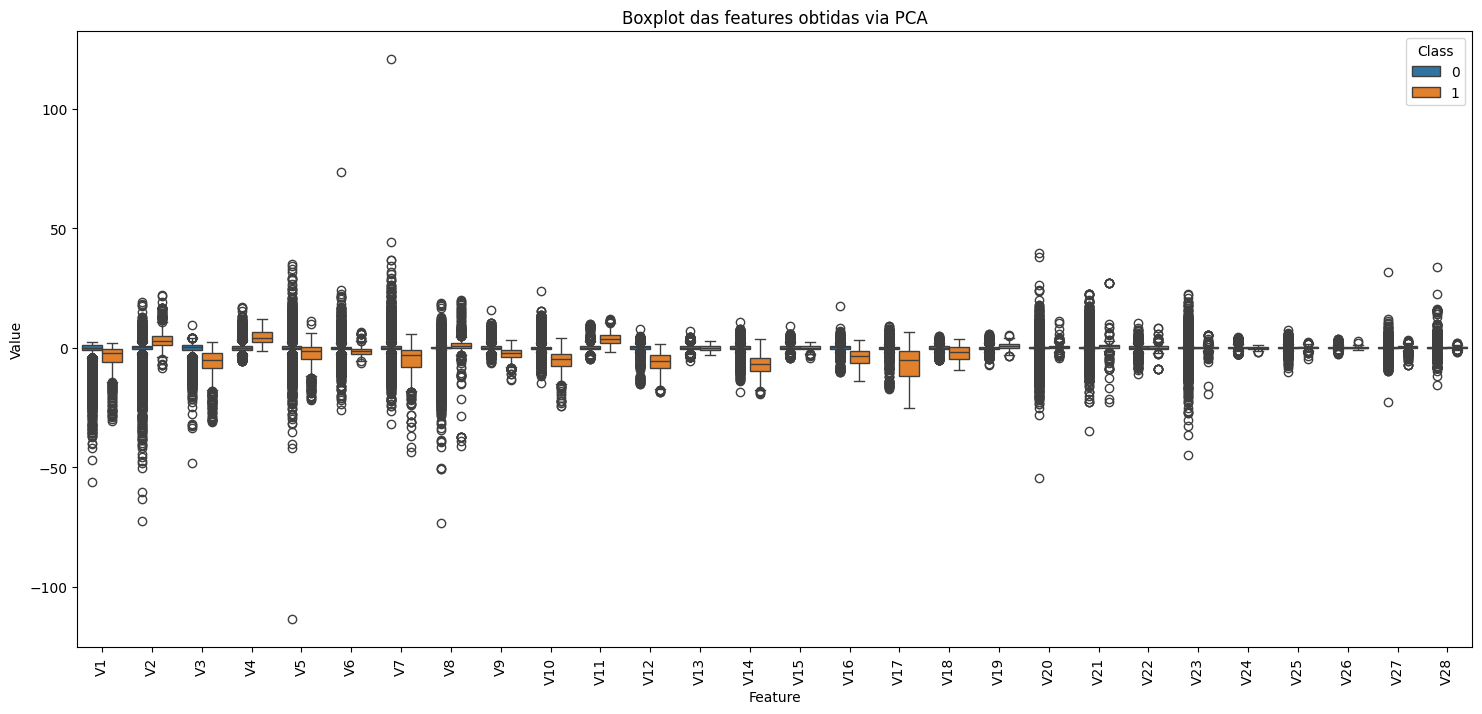

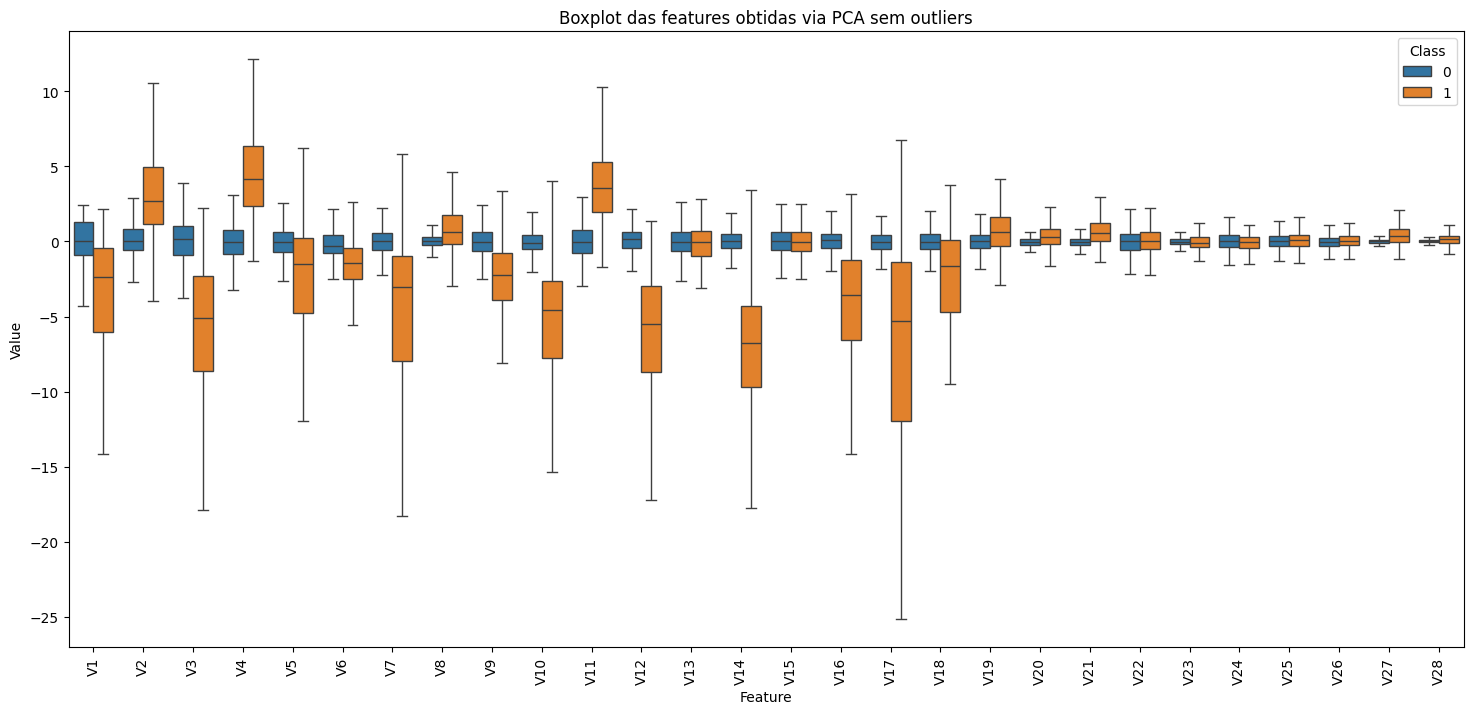

In [ ]:
features = database.drop(columns=['Time', 'Amount','Class'])

melted = pd.melt(database, id_vars='Class', value_vars=features.columns,
                 var_name='Feature', value_name='Value')

plt.figure(figsize=(18, 8))
sns.boxplot(x='Feature', y='Value', hue='Class', data=melted)

plt.xticks(rotation=90)
plt.title('Boxplot das features obtidas via PCA')

plt.show()

plt.figure(figsize=(18, 8))
sns.boxplot(x='Feature', y='Value', hue='Class', data=melted, showfliers=False)

plt.xticks(rotation=90)
plt.title('Boxplot das features obtidas via PCA sem outliers')

plt.show()

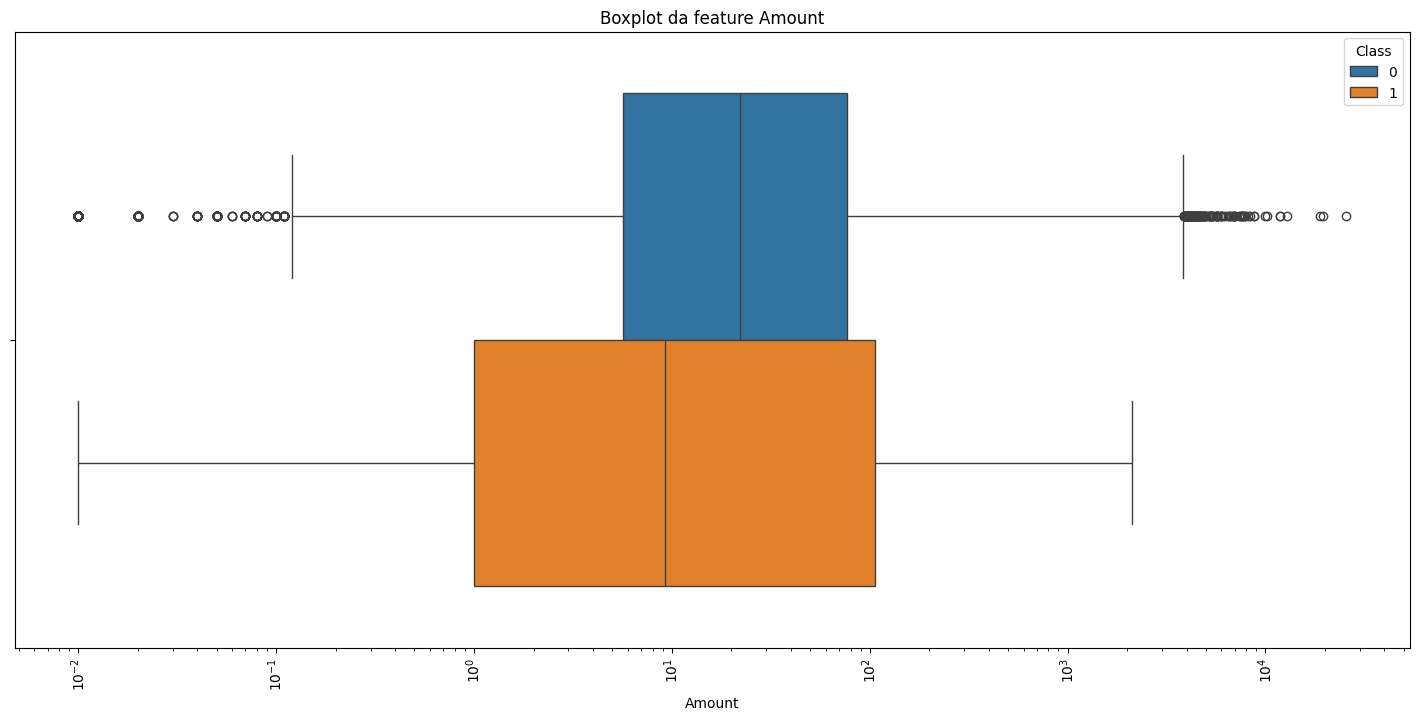

In [ ]:
plt.figure(figsize=(18, 8))
sns.boxplot(x='Amount', hue='Class', data=database, log_scale=True)

plt.xticks(rotation=90)
plt.title('Boxplot da feature Amount')

plt.show()

### Pré-processamentos

In [ ]:
# Procurando por valores faltantes

print('Missing values:')

database.isnull().sum()

Missing values:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Procurando por valores categóricos

print(f'{len(database.select_dtypes(include="object").columns)} atributos categóricos')

0 atributos categóricos


In [3]:
def database_preprocessing(database):
   processed_database = database.copy()

   # Optei por retirar a coluna temporal ('Time'), por ser apenas os segundos passados entre cada transação e a primeira transação do dataset
   processed_database = processed_database.drop(columns=['Time'])

   # Retira linhas (transações) que possuem valores faltantes (neste caso este passo não seria necessário por não possuir valores faltantes)
   processed_database = processed_database.dropna()

   # X: Features
   X = processed_database.drop(columns=['Class'])
   # y: rótulos (classes)
   y = processed_database['Class']

   # Divisão do dataset em treino e teste como estratégia para generalização
   # Aqui foram separados, mantendo o mesmo balanceamento entre as classes, 20% dos dados apenas teste de performance, não sendo usados no treinamento
   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

   # Escalonamento: Aplicação de Normalização (Standard Scaler) nas colunas de features
   scaler = StandardScaler()
   X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
   X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)

   processed_database_train = pd.concat([X_train_scaled.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
   processed_database_test = pd.concat([X_test_scaled.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)


   return processed_database, processed_database_train, processed_database_test

In [4]:
processed_database, processed_database_train, processed_database_test = database_preprocessing(database)
processed_database_train.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.993379,-0.456037,-0.894052,-0.467284,1.089217,3.024383,-1.194852,0.957057,1.281376,-0.144546,...,0.103171,0.409563,0.490685,1.141970,-0.670832,-0.807227,0.191912,-0.099106,-0.322494,0
1,1.038507,-0.029349,-2.018302,0.175133,2.133506,2.478840,-0.001832,0.566704,0.041121,0.262604,...,0.052055,0.314019,0.056568,1.168583,0.985238,-0.977976,0.006397,-0.211524,-0.339764,0
2,-0.506766,0.366065,0.470114,-0.700918,-0.598748,1.470411,-1.786684,-4.227592,0.000064,-1.849641,...,-3.807987,0.150500,-0.695838,-1.540549,1.587269,1.895777,0.094137,0.566426,0.346693,0
3,1.166419,-0.909447,-0.493095,-1.178149,-1.010692,-0.262292,-1.153123,0.008765,-1.019866,1.617041,...,-0.190540,0.105701,0.331932,-0.888718,-0.532153,-0.336546,0.044738,-0.193183,-0.327360,0
4,-0.229485,-0.613041,0.076742,-2.440089,0.518711,-0.109914,0.407186,-0.095161,-0.041449,-0.514215,...,-0.331467,-0.239208,-0.010747,-2.250223,-0.559400,-0.300345,-0.080285,-0.196818,-0.008281,0
5,0.673663,-0.946286,-0.101592,-1.275662,-0.602732,0.660292,-0.979138,0.206847,-1.593476,1.398162,...,-0.471972,-1.297365,-0.166352,-2.957115,0.354646,-0.620711,0.064041,0.048640,0.148027,0
6,0.970629,0.096529,-0.138396,2.443222,0.250686,1.101989,-0.605121,0.363461,-0.356160,1.431781,...,0.283247,0.890378,0.119993,-0.291586,-0.181488,0.186685,0.010906,-0.140257,-0.345667,0
7,1.067524,-0.611851,-0.584230,-0.299630,-0.417360,0.366360,-0.834284,0.169524,0.239309,0.731688,...,-0.215510,0.336995,0.133749,0.192239,0.064045,-0.256117,0.104975,-0.158106,-0.303868,0
8,-1.689954,-3.433693,0.307864,-0.303749,2.655783,-2.279853,-2.294624,0.437217,1.353380,-0.459601,...,1.114664,1.022614,2.781630,-0.810445,-4.131060,0.359690,0.296256,1.429598,0.480308,0
9,1.007277,-0.245059,-0.146302,0.377507,-0.601846,-0.469714,-0.481315,-0.055738,1.335152,-0.152471,...,0.264649,1.132462,0.191277,0.119763,-0.186057,-0.448115,0.103649,-0.110904,-0.311845,0


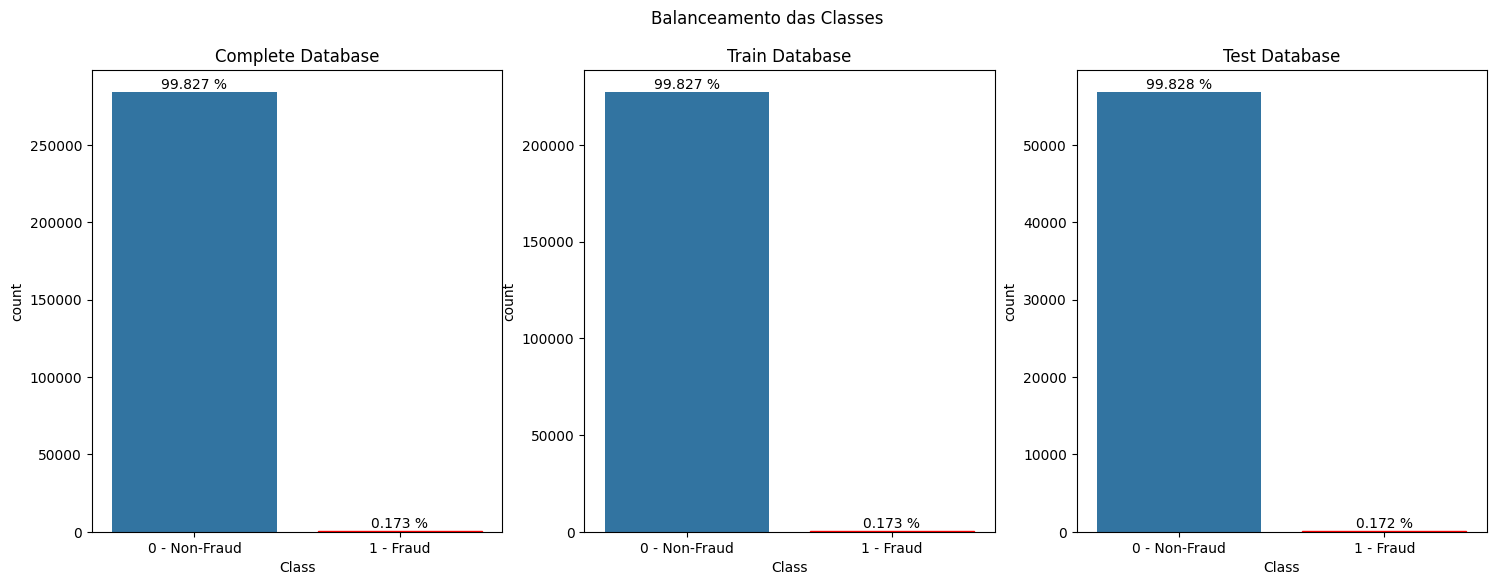

In [5]:
ax, fig = plt.subplots(1,3, figsize=(18, 6))
plt.suptitle('Balanceamento das Classes')
split_names = {0: 'Complete Database', 1: 'Train Database', 2: 'Test Database'}

for i, split in enumerate([processed_database, processed_database_train, processed_database_test]):
  ax = sns.countplot(x='Class', data=split, ax=fig.flatten()[i])
  ax.set_title(split_names[i])

  for p in ax.patches:
      ax.text(
          p.get_x() + p.get_width() / 2,
          p.get_height(),
          f'{(p.get_height()/len(split))*100:.3f} %',
          ha='center',
          va='bottom'
      )
  ax.set_xticks(range(len(ax.patches)))
  ax.set_xticklabels(['0 - Non-Fraud', '1 - Fraud'])
  ax.patches[1].set_color('red')

## 2. Abordagem 1: Modelagem da Classe Normal (Detecção de Anomalia)

### Isolamento dos dados não fraudulentos

In [6]:
processed_database_train_normal = processed_database_train[processed_database_train['Class'] == 0]

### Ajuste de modelos generativos probabilísticos



#### Gaussiana Multivariada

O primeiro modelo escolhido foi a Gaussiana Multivariada, pois a Gaussiana permite capturar a correlação entre atributos, a estimativa de parâmetros é fácil via MLE, possui uma boa eficiência computacional, além de as features obtidas via PCA da classe normal possuirem um comportamento que se assemelha a Gausianas, o que é uma suposição neste modelo.

In [7]:
# Ajuste via MLE
X_normal = processed_database_train_normal.drop(columns=['Class'])
y_normal = processed_database_train_normal['Class']

# Média
mean = np.mean(X_normal, axis=0)

# Matriz de covariância
cov = np.cov(X_normal, rowvar=False)

print(mean.shape, cov.shape)

(29,) (29, 29)


- Cálculo dos scores de anomalia
    - Foi escolhido para o cálculo a distância de Mahalanobis

In [8]:
# Para todos os dados de treino
X = processed_database_train.drop(columns=['Class'])
y = processed_database_train['Class']

# Cálculo das distâncias de Mahalanobis
mahalanobis_distances = np.array([mahalanobis(x, mean, inv(cov)) for x in X.values])

mahalanobis_df = pd.DataFrame({'Class': y, 'Mahalanobis Distance': mahalanobis_distances}).reset_index(drop=True)
mahalanobis_df.head(10)

,Class,Mahalanobis Distance
0,0,4.817906
1,0,4.732634
2,0,8.221750
3,0,3.727599
4,0,4.852892
5,0,4.813851
6,0,4.902462
7,0,3.861021
8,0,8.618661
9,0,2.753395


- Distribuções dos scores por classe

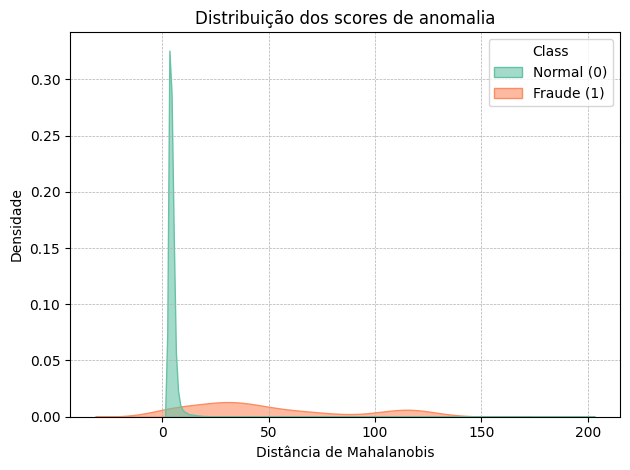

In [10]:
plt.title('Distribuição dos scores de anomalia')
label_map = {0: 'Normal (0)', 1: 'Fraude (1)'}
mahalanobis_df_plot = mahalanobis_df.copy()
mahalanobis_df_plot['Class'] = mahalanobis_df_plot['Class'].map(label_map)

ax = sns.kdeplot(
      data=mahalanobis_df_plot,
      x='Mahalanobis Distance',
      hue='Class',
      common_norm=False,
      palette='Set2',
      alpha=0.6,
      fill = True
)
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xlabel('Distância de Mahalanobis')
ax.set_ylabel('Densidade')
plt.tight_layout(h_pad=2.0)
plt.show()

- Seleção de limiar para classificar como fraude

    - Utilizarei a análise da curva precision-recall (PR)

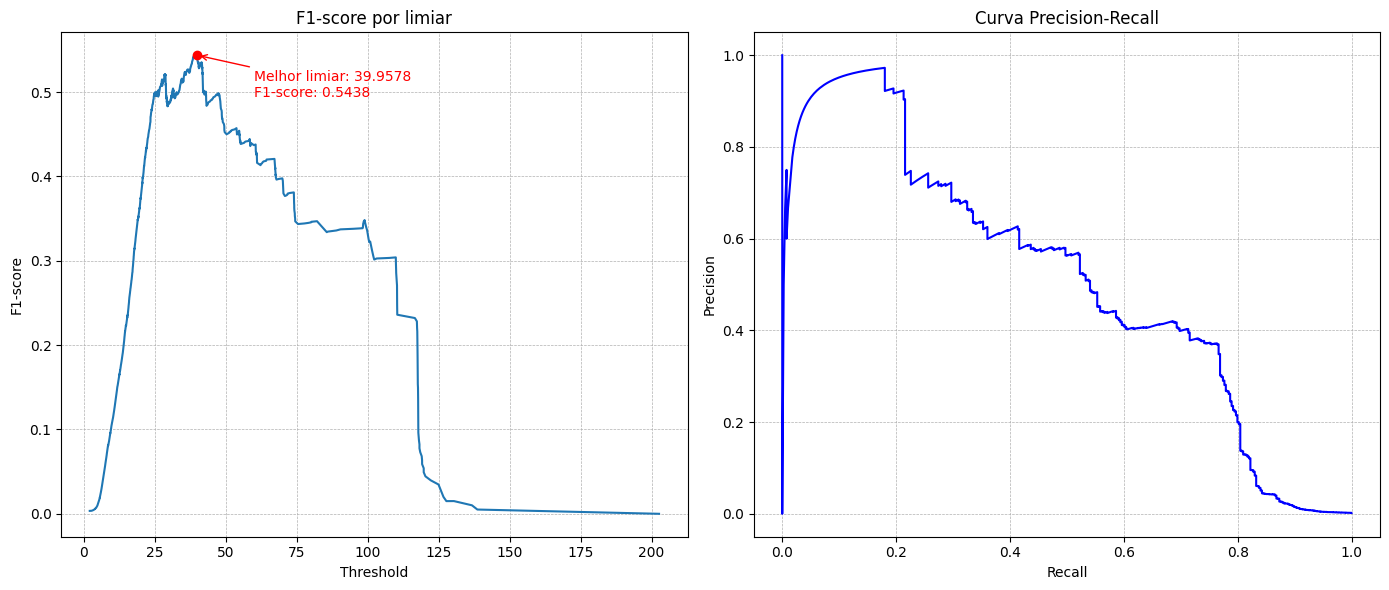

Melhor limiar: 39.95775336868743
Melhor f1-score: 0.5437665782493368


In [21]:
# curva precision-recall

precision, recall, thresholds = precision_recall_curve(mahalanobis_df['Class'], mahalanobis_df['Mahalanobis Distance'])

# Cálculo dos f1-scores para cada limiar
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-50)

# Melhor limiar e f1-score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Calculo dos f1-scores para cada limiar (usarei o limiar de maior f1-score)
axs[0].plot(thresholds, f1_scores[:-1])
axs[0].plot(best_threshold, best_f1, 'ro')
axs[0].annotate(f'Melhor limiar: {best_threshold:.4f}\nF1-score: {best_f1:.4f}',
                xy=(best_threshold, best_f1),
                xytext=(best_threshold + 20, best_f1 - 0.05),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10, color='red')

# Limiares
axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('F1-score')
axs[0].set_title('F1-score por limiar')
axs[0].grid(True, linestyle='--', linewidth=0.5)

# Curva Precision-Recall
axs[1].plot(recall, precision, color='blue')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Curva Precision-Recall')
axs[1].grid(True, linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()


print(f'Melhor limiar: {best_threshold}')
print(f'Melhor f1-score: {best_f1}')

- Avaliação de performance

Metrics:
Precision normal: 0.9991910523353967
Precision fraude: 0.5306122448979592
Recall normal: 0.9991910523353967
Recall fraude: 0.5306122448979592
F1-score normal: 0.9991910523353967
F1-score fraude: 0.5306122448979592
AUC: 0.5319252204321774
Matriz de Confusão:


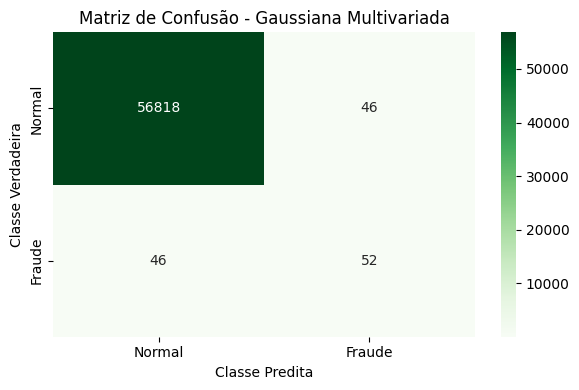

In [24]:
X_test = processed_database_test.drop(columns=['Class'])
y_test = processed_database_test['Class']

# Calculando as distâncias de mahalanobis para o conjunto de teste
mahalanobis_distances = np.array([
    mahalanobis(x, mean, inv(cov)) for x in X_test.values
])

y_pred_test = (mahalanobis_distances > best_threshold).astype(int)

print('Metrics:')
precision = precision_score(y_test, y_pred_test, average=None)
print('Precision normal:', precision[0])
print('Precision fraude:', precision[1])
recall = recall_score(y_test, y_pred_test, average=None)
print('Recall normal:', recall[0])
print('Recall fraude:', recall[1])
f1 = f1_score(y_test, y_pred_test, zero_division=0, average=None)
print('F1-score normal:', f1[0])
print('F1-score fraude:', f1[1])
auc = average_precision_score(y_test, mahalanobis_distances)
print('AUC:', auc)

print('Matriz de Confusão:')
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Normal", "Fraude"],
            yticklabels=["Normal", "Fraude"])
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão - Gaussiana Multivariada")
plt.tight_layout()
plt.show()


## 3. Abordagem 2: Modelo como Classificação Supervisionada

- Regressão Logística

Metrics:
Precision normal: 0.9993847343810428
Precision fraude: 0.8289473684210527
Recall normal: 0.9997713843556556
Recall fraude: 0.6428571428571429
F1-score normal: 0.9995780219780219
F1-score fraude: 0.7241379310344828
AUC: 0.7420872102277538
Matriz de Confusão:


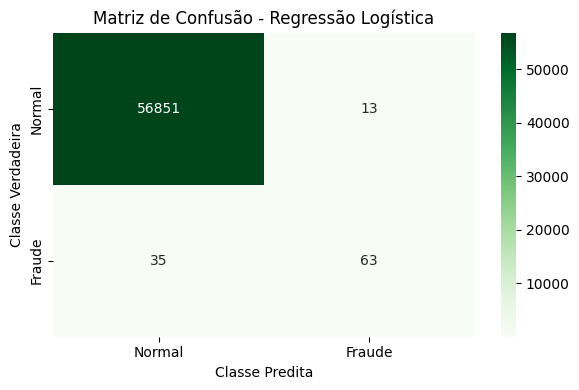

In [28]:
# Obtenção dos dados
x_train = processed_database_train.drop(columns=['Class'])
y_train = processed_database_train['Class']

X_test = processed_database_test.drop(columns=['Class'])
y_test = processed_database_test['Class']

# Treinamento de modelo de Regressão Logística
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(x_train, y_train)

# Predições
p_fraude = log_reg.predict_proba(X_test)[:, 1]
y_pred_test = log_reg.predict(X_test)

# Obtenção das métricas para o conjunto de teste
print('Metrics:')
precision = precision_score(y_test, y_pred_test, average=None)
print('Precision normal:', precision[0])
print('Precision fraude:', precision[1])
recall = recall_score(y_test, y_pred_test, average=None)
print('Recall normal:', recall[0])
print('Recall fraude:', recall[1])
f1 = f1_score(y_test, y_pred_test, zero_division=0, average=None)
print('F1-score normal:', f1[0])
print('F1-score fraude:', f1[1])
auc = average_precision_score(y_test, p_fraude)
print('AUC:', auc)

print('Matriz de Confusão:')
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Normal", "Fraude"],
            yticklabels=["Normal", "Fraude"])
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão - Regressão Logística")
plt.tight_layout()
plt.show()



## 4. Análise da Distribuição dos Scores do Classificador e Limiarização

### Regressor Logístico

- Scores (probabilidade de fraude) utilizando validação cruzada
  - Método: k-fold de 5 pastas

In [29]:
# Divisão dos dados de treinamento em 5 pastas (k-fold) para validação cruzada
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_opt = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
p_fraudes = {}
y_vals = {}
for i, (train_index, val_index) in enumerate(kf.split(x_train, y_train)):
    X_train, X_val = x_train.iloc[train_index], x_train.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    log_reg_opt.fit(X_train, y_train)
    p_fraude = log_reg_opt.predict_proba(X_val)[:, 1]

    p_fraudes[i] = p_fraude
    y_vals[i] = y_val


- Distribuções dos scores por classe

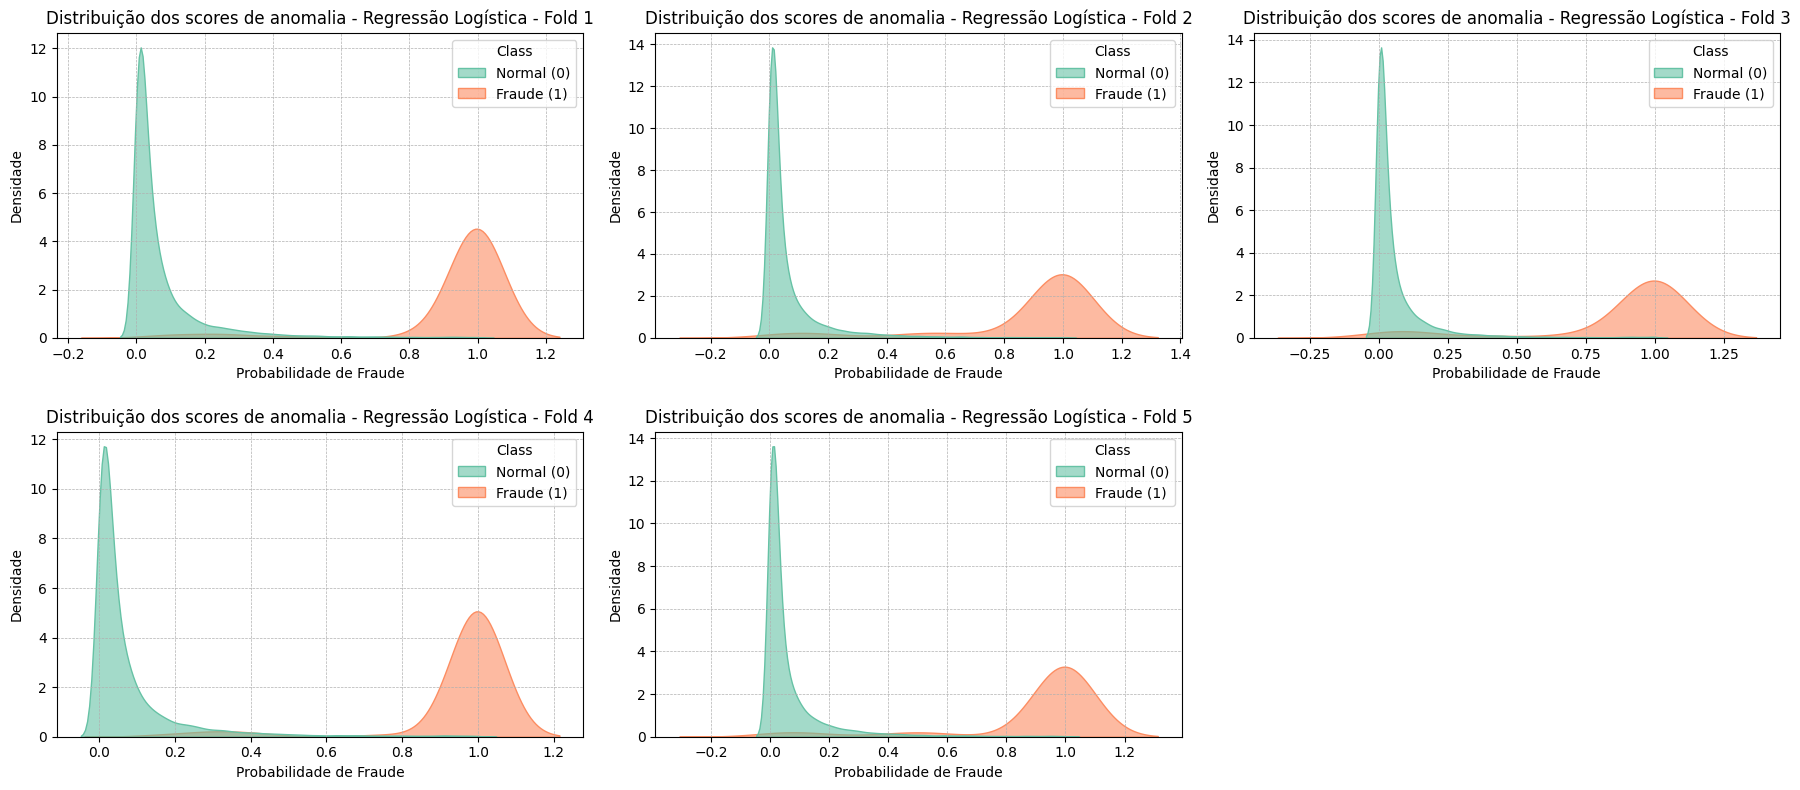

In [31]:
# Obtenção dos scores de anomalia para todos os 5 splits de validação
label_map = {0: 'Normal (0)', 1: 'Fraude (1)'}

fig, ax = plt.subplots(2, 3, figsize=(18, 8))
ax = ax.flatten()

for i in range(5):
  ax[i].set_title(f'Distribuição dos scores de anomalia - Regressão Logística - Fold {i + 1}')

  y_val_plot = y_vals[i].map(label_map)
  sns.kdeplot(
        x=p_fraudes[i],
        hue=y_val_plot,
        common_norm=False,
        palette='Set2',
        alpha=0.6,
        fill = True,
        ax = ax[i]
  )
  ax[i].grid(True, linestyle='--', linewidth=0.5)
  ax[i].set_xlabel('Probabilidade de Fraude')
  ax[i].set_ylabel('Densidade')

fig.delaxes(ax[5])

plt.tight_layout(h_pad=2.0)
plt.show()

- Seleção de limiar para classificar como fraude

Melhor limiar fold 1: 0.9999999937640258
Melhor f1-score 1: 0.8356164383561644
Melhor limiar fold 2: 0.9999997888216943
Melhor f1-score 2: 0.8137931034482758
Melhor limiar fold 3: 0.9999999997500855
Melhor f1-score 3: 0.7919463087248322
Melhor limiar fold 4: 0.9999807364243831
Melhor f1-score 4: 0.8198757763975155
Melhor limiar fold 5: 0.9999999669294306
Melhor f1-score 5: 0.8211920529801324


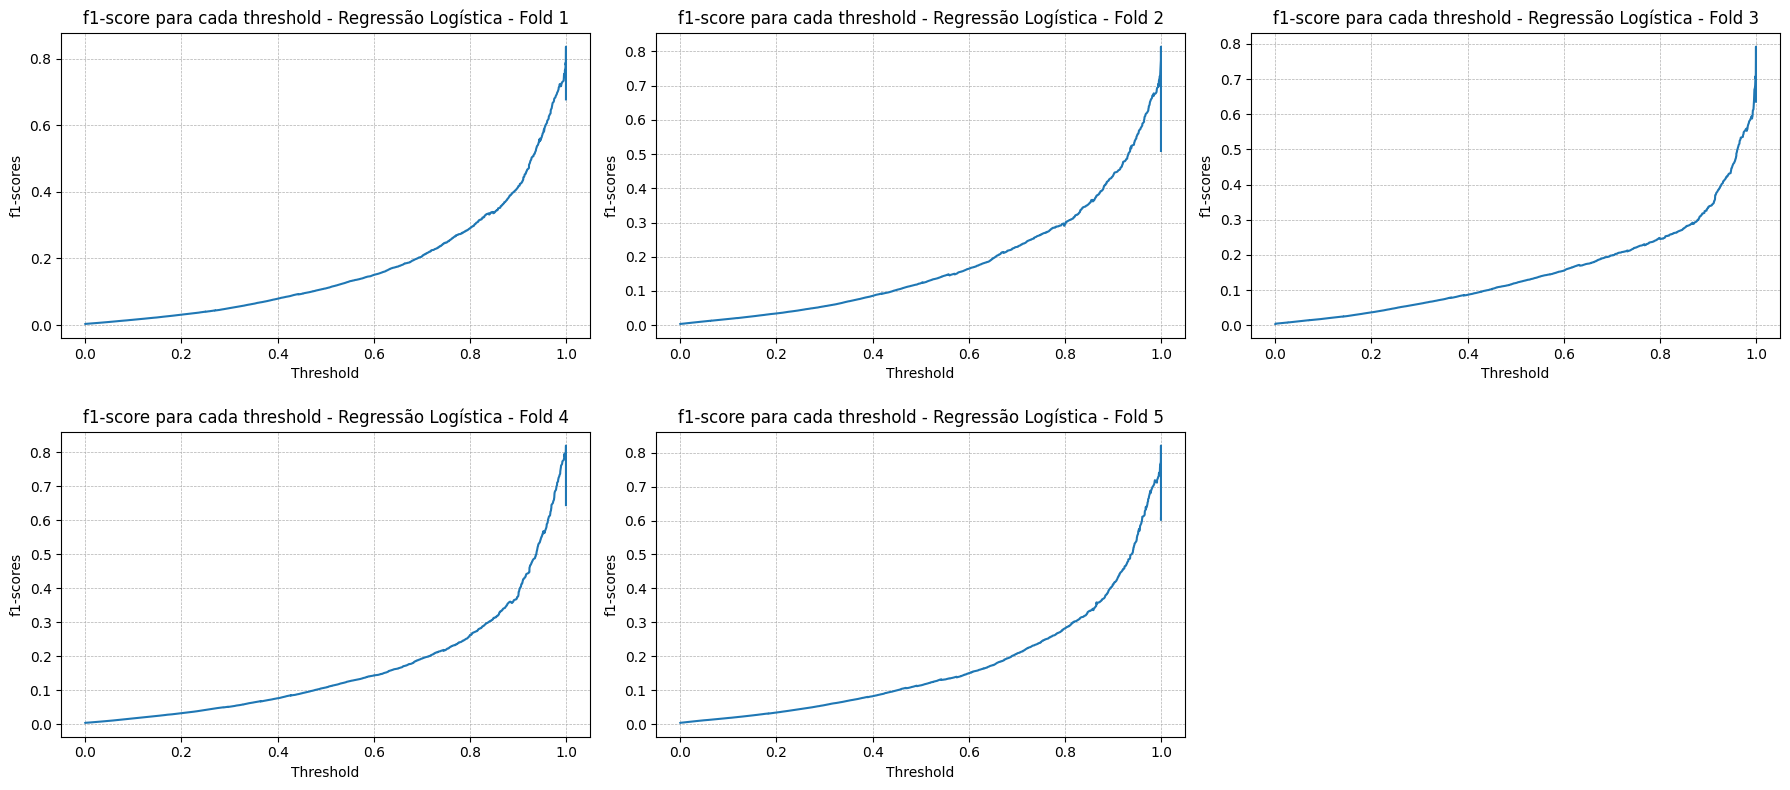

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8))
ax = ax.flatten()

for i in range(5):
  ax[i].set_title(f'f1-score para cada threshold - Regressão Logística - Fold {i + 1}')

  # curva precision-recall
  precision, recall, thresholds = precision_recall_curve(y_vals[i], p_fraudes[i])

  # Calculo dos f1-scores para cada limiar (usarei o limiar de maior f1-score)
  f1_scores = 2 * (precision * recall) / (precision + recall + 10**-50)

  ax[i].plot(thresholds, f1_scores[:-1])
  ax[i].set_xlabel('Threshold')
  ax[i].set_ylabel('f1-scores')
  ax[i].grid(True, linestyle='--', linewidth=0.5)

  # Obtenção dos melhores thresholds
  best_threshold = thresholds[np.argmax(f1_scores)]
  best_f1 = f1_scores[np.argmax(f1_scores)]

  print(f'Melhor limiar fold {i+1}: {best_threshold}')
  print(f'Melhor f1-score {i+1}: {best_f1}')

fig.delaxes(ax[5])

plt.tight_layout(h_pad=2.0)
plt.show()

- Visualização do score e curva PR para o split de validação de melhor desempenho

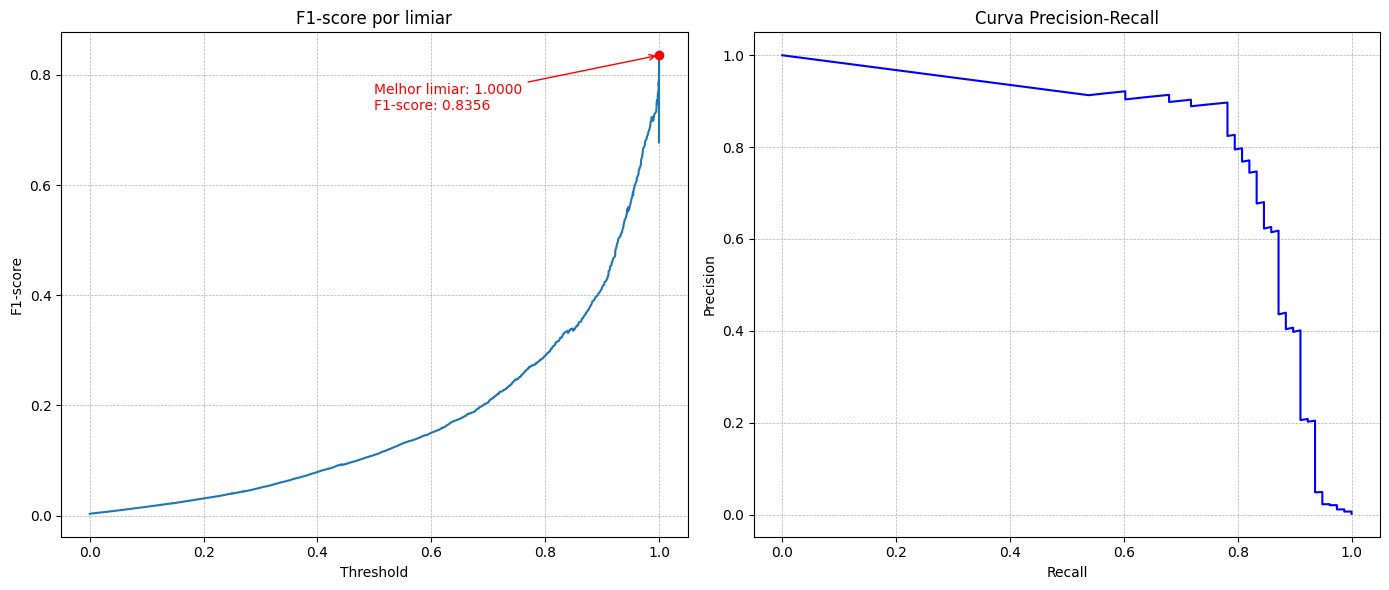

In [39]:
# Curva precision-recall
precision, recall, thresholds = precision_recall_curve(y_vals[0], p_fraudes[0])

# Cálculo dos f1-scores para cada limiar
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-50)

# Melhor limiar e f1-score
best_index = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Limiares
axs[0].plot(thresholds, f1_scores[:-1], label='F1-score')
axs[0].plot(best_threshold, best_f1, 'ro')
axs[0].annotate(f'Melhor limiar: {best_threshold:.4f}\nF1-score: {best_f1:.4f}',
                xy=(best_threshold, best_f1),
                xytext=(best_threshold - 0.5, best_f1 - 0.1),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10, color='red')

axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('F1-score')
axs[0].set_title('F1-score por limiar')
axs[0].grid(True, linestyle='--', linewidth=0.5)

# Curva Precision-Recall
axs[1].plot(recall, precision, color='blue', label='Precision-Recall')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Curva Precision-Recall')
axs[1].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

- Avaliação de Performance

Metrics:
Precision normal: 0.9996483083632272
Precision fraude: 0.8297872340425532
Recall normal: 0.9997186268992684
Recall fraude: 0.7959183673469388
F1-score normal: 0.9996834663946822
F1-score fraude: 0.8125
AUC: 0.7226328127693876
Matriz de Confusão:


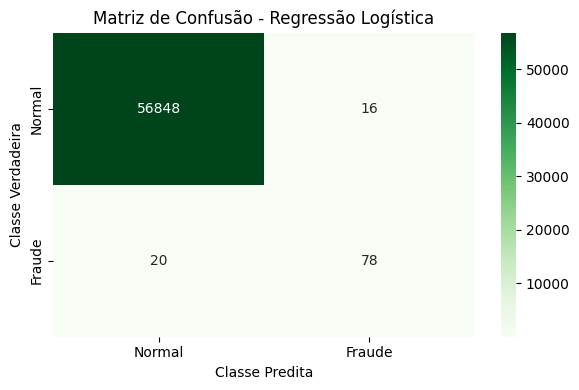

In [40]:
X_test = processed_database_test.drop(columns=['Class'])
y_test = processed_database_test['Class']

# probabilidades para o conjunto de teste
p_fraude_test = log_reg_opt.predict_proba(X_test)[:, 1]

y_pred_test = (p_fraude_test > best_threshold).astype(int)

print('Metrics:')
precision = precision_score(y_test, y_pred_test, average=None)
precision
print('Precision normal:', precision[0])
print('Precision fraude:', precision[1])
recall = recall_score(y_test, y_pred_test, average=None)
print('Recall normal:', recall[0])
print('Recall fraude:', recall[1])
f1 = f1_score(y_test, y_pred_test, zero_division=0, average=None)
print('F1-score normal:', f1[0])
print('F1-score fraude:', f1[1])
auc = average_precision_score(y_test, p_fraude_test)
print('AUC:', auc)

print('Matriz de Confusão:')
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Normal", "Fraude"],
            yticklabels=["Normal", "Fraude"])
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão - Regressão Logística")
plt.tight_layout()
plt.show()

# Parte 2: Exercícios Teóricos-Conceituais

## Exercício 3: Decomposição Bias-Variância

- Geração de dataset sintético:
    - função geradora: f(x)=cos(4πx)
    - 30 pontos de dados

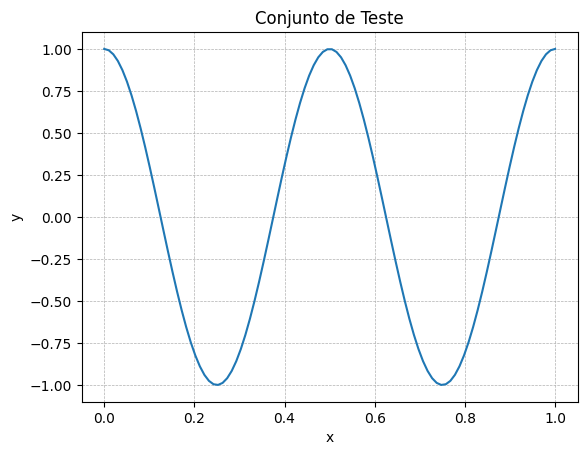

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

# Gerar dados sintéticos para o conjunto de teste
np.random.seed(0)
samples = 30
std_noise = 0.3
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test = np.cos(4 * np.pi * x_test).ravel()

plt.plot(x_test, y_test)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Conjunto de Teste')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

- Gerando 100 datasets de treino
    - Adição de ruído Gaussiano com desvio padrão de 0.3.

In [ ]:
datasets = []
for _ in range(100):
    x_train = np.random.rand(samples, 1)
    y_train = np.cos(4 * np.pi * x_train).ravel() + np.random.normal(0, std_noise, size=samples)
    datasets.append((x_train, y_train))

- Fit de Regressão Ridge com lambda decrescente fixando uma regressão de um polinômio de grau 5

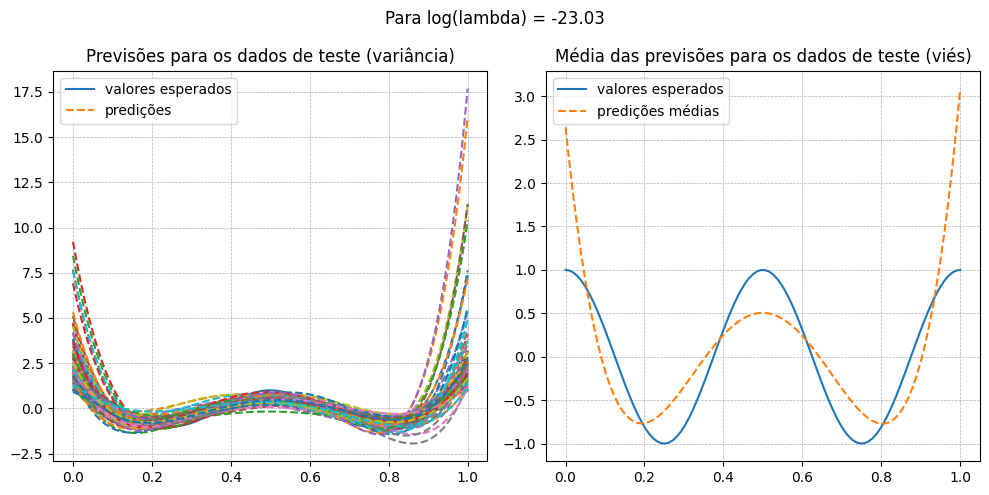

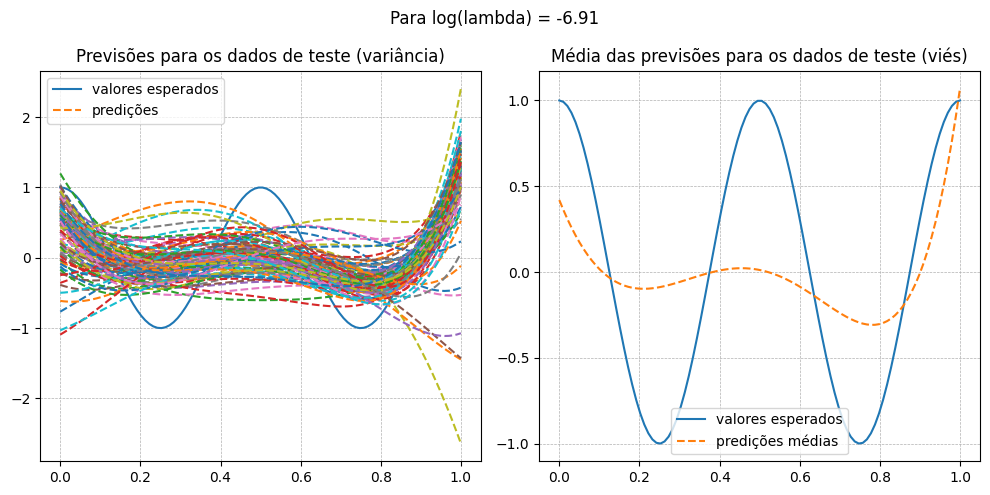

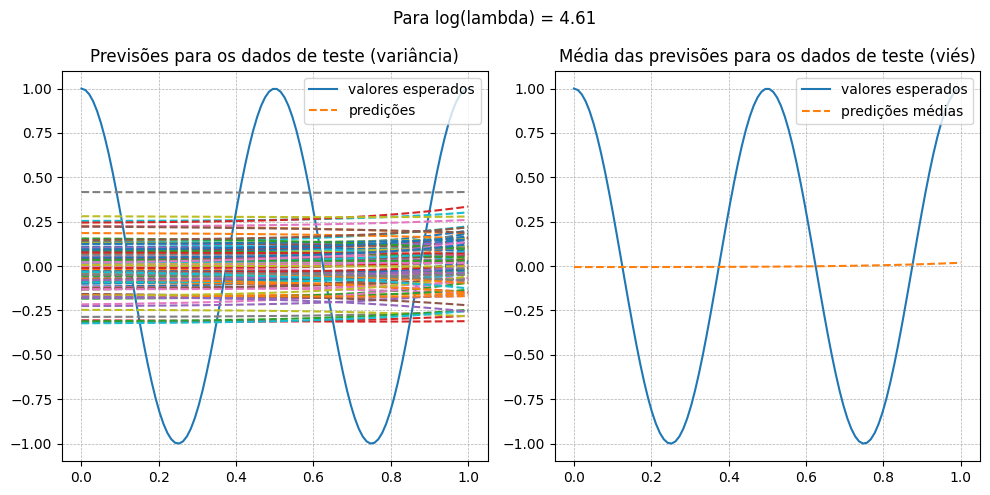

In [ ]:
# Regressor Polinomial
poly = PolynomialFeatures(degree=5)

# fit nos dados de teste
X_test_poly = poly.fit_transform(x_test)

#Teste para valores baixos, médios e altos do coeficiente de regularização
for lam in [10**-10, 10**-3, 100]:
    predictions = []
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax = ax.flatten()
    fig.suptitle(f'Para log(lambda) = {np.log(lam):.2f}')
    ax[0].plot(x_test, y_test, label='valores esperados')
    ax[0].set_title('Previsões para os dados de teste (variância)')
    ax[1].set_title('Média das previsões para os dados de teste (viés)')
    label = 'predições'
    for i, (x_train, y_train) in enumerate(datasets):
        if i > 0:
            label = None

        # fit nos dados de treino
        X_train_poly = poly.fit_transform(x_train)

        # Treinando o regressor Ridge
        model = Ridge(alpha=lam)
        model.fit(X_train_poly, y_train)

        # Predição do modelo nos dados de teste
        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)

        ax[0].plot(x_test, y_pred, '--', label=label)


    # conjunto de predições
    predictions = np.array(predictions)
    # média das predições
    mean_prediction = np.mean(predictions, axis=0)


    ax[1].plot(x_test, y_test, label='valores esperados')
    ax[1].plot(x_test, mean_prediction, '--',label='predições médias')

    ax[0].legend()
    ax[1].legend()
    ax[0].grid(True, linestyle='--', linewidth=0.5)
    ax[1].grid(True, linestyle='--', linewidth=0.5)

    plt.tight_layout(h_pad=2.0)
    plt.show()

- Visualização viés-variância

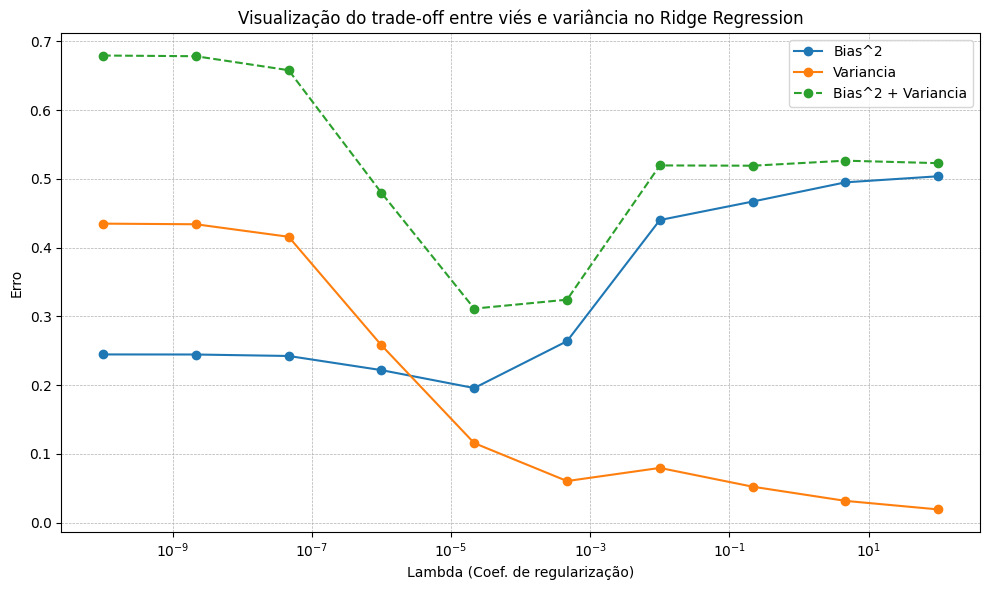

In [ ]:
# Regressor Polinomial
poly = PolynomialFeatures(degree=5)

# Parâmetros de regularização (lambdas) a serem testados
lambdas = np.logspace(-10, 2, 10)

bias_squared_list = []
variance_list = []
mse_list = []

# fit nos dados de teste
X_test_poly = poly.fit_transform(x_test)

for lam in lambdas:
    predictions = []

    for x_train, y_train in datasets:
        # fit nos dados de treino
        X_train_poly = poly.fit_transform(x_train)

        # Treinando o regressor Ridge
        model = Ridge(alpha=lam)
        model.fit(X_train_poly, y_train)

        # Predição do modelo nos dados de teste
        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)

    predictions = np.array(predictions)
    mean_prediction = np.mean(predictions, axis=0)

    # Calculando bias^2, variancia, and erro quadrático
    bias_squared = np.mean((mean_prediction - y_test) ** 2)
    variance = np.mean(np.var(predictions, axis=0))
    mse = bias_squared + variance

    bias_squared_list.append(bias_squared)
    variance_list.append(variance)
    mse_list.append(mse)


plt.figure(figsize=(10, 6))
plt.plot(lambdas, bias_squared_list, label='Bias^2', marker='o')
plt.plot(lambdas, variance_list, label='Variancia', marker='o')
plt.plot(lambdas, mse_list, label='Bias^2 + Variancia', marker='o', linestyle='--')
plt.xscale('log')
plt.xlabel('Lambda (Coef. de regularização)')
plt.ylabel('Erro')
plt.title('Visualização do trade-off entre viés e variância no Ridge Regression')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

